In [1]:
!pip install scipy
!pip install seaborn
!pip install scikit-learn
!pip install tensorflow

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input,Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [3]:
 data = pd.read_csv(r"C:\Users\PC\Desktop\Mes etudes\France studies\Cours Capteur inte paris saclay\project de fin d'etude\IoTProcessed_Data.csv")

In [4]:
data.head(10)

,date,tempreature,humidity,water_level,N,P,K,Fan_actuator_OFF,Fan_actuator_ON,Watering_plant_pump_OFF,Watering_plant_pump_ON,Water_pump_actuator_OFF,Water_pump_actuator_ON
0,2024-02-08 06:10:00,41,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
1,2024-02-08 06:15:00,41,59,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
2,2024-02-08 06:20:00,41,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
3,2024-02-08 06:05:00,40,60,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
4,2024-02-08 06:00:00,39,61,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
5,2024-01-18 06:02:00,38,64,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
6,2024-01-18 06:07:00,38,65,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
7,2024-01-18 06:12:00,38,64,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
8,2024-01-18 05:02:00,37,62,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0
9,2024-01-18 05:07:00,37,63,100,255,255,255,0.0,1.0,1.0,0.0,1.0,0.0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37922 entries, 0 to 37921
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   date                     37920 non-null  object 
 1   tempreature              37922 non-null  int64  
 2   humidity                 37922 non-null  int64  
 3   water_level              37922 non-null  int64  
 4   N                        37922 non-null  int64  
 5   P                        37922 non-null  int64  
 6   K                        37922 non-null  int64  
 7   Fan_actuator_OFF         37922 non-null  float64
 8   Fan_actuator_ON          37922 non-null  float64
 9   Watering_plant_pump_OFF  37922 non-null  float64
 10  Watering_plant_pump_ON   37922 non-null  float64
 11  Water_pump_actuator_OFF  37922 non-null  float64
 12  Water_pump_actuator_ON   37922 non-null  float64
dtypes: float64(6), int64(6), object(1)
memory usage: 3.8+ MB


In [6]:
data.columns

Index(['date', 'tempreature', 'humidity', 'water_level', 'N', 'P', 'K',
       'Fan_actuator_OFF', 'Fan_actuator_ON', 'Watering_plant_pump_OFF',
       'Watering_plant_pump_ON', 'Water_pump_actuator_OFF',
       'Water_pump_actuator_ON'],
      dtype='object')

In [7]:
#Create a new table with only the variables I need for my autonomous greenhouse
new_table=['tempreature', 'humidity','Watering_plant_pump_ON']
My_table=data[new_table]
My_table = My_table.copy()  # Crée une copie indépendante
My_table['Watering_plant_pump_ON'] = My_table['Watering_plant_pump_ON'].astype(int)

In [8]:
My_table

,tempreature,humidity,Watering_plant_pump_ON
0,41,63,0
1,41,59,0
2,41,62,0
3,40,60,0
4,39,61,0
...,...,...,...
37917,3,59,0
37918,3,60,0
37919,3,60,0
37920,3,59,0


In [9]:
# Change the type of the 'temperature' and 'humidity' columns to float
My_table = My_table.copy()
My_table[['tempreature', 'humidity']] = My_table[['tempreature', 'humidity']].astype(float)

In [10]:
#look for the null values
Null_values=My_table.isnull().sum()

In [11]:
Null_values

tempreature               0
humidity                  0
Watering_plant_pump_ON    0
dtype: int64

In [12]:
#Define the threshold
seuil_refroidissement = 25

# Ajouter une colonne 'Peltier_Action'
My_table['Ventilateur_froid'] = 0
My_table.loc[My_table['tempreature'] > seuil_refroidissement, 'Ventilateur_froid'] = 1

In [13]:
# Guidelines for the Peltier module
My_table['Peltier_Action'] = np.where(
    My_table['tempreature'] > 25, 1, 0
)

In [14]:
#Define the threshold
seuil_chauffage = 12

# Ajouter une colonne 'Peltier_Action'
My_table['Ventilateur_chauffage'] = 0
My_table.loc[My_table['tempreature'] < seuil_chauffage, 'Ventilateur_chauffage'] = 1

In [15]:
# Guidelines for the heating pad
My_table['Heating_pad_Action'] = np.where(
    My_table['tempreature'] < 12, 1, 0
)

In [16]:
# Generate timestamps for an entire day (24 hours)
timestamps = pd.date_range(start="2023-01-01 00:00", end="2023-01-01 23:00", freq="h")

# Calculate the number of repetitions needed to cover all rows
num_repeats = len(My_table) // len(timestamps) + (len(My_table) % len(timestamps) > 0)

# Extend the timestamps to match the number of rows in the DataFrame
timestamps_repeated = np.tile(timestamps, num_repeats)[:len(My_table)]

# Convert numpy.datetime64 to pandas.Timestamp before accessing the hour
timestamps_repeated = pd.to_datetime(timestamps_repeated)

# Determine the lamp status: 1 (ON from 6 AM to 8 PM), otherwise 0 (OFF)
lamp_status = []

# Loop through the timestamps and apply the lamp status logic
for ts in timestamps_repeated:
    if 6 <= ts.hour < 20: 
        lamp_status.append(1)
    else:  
        lamp_status.append(0)

# Add the columns to the database
My_table['Timestamp'] = timestamps_repeated
My_table['Lamp_Status'] = lamp_status

# Convert 'Timestamp' to seconds since the epoch
My_table['Timestamp_seconds'] = My_table['Timestamp'].astype('int64') // 10**9
My_table = My_table.drop(columns=['Timestamp'])

In [17]:
My_table[['tempreature','humidity']].describe()

,tempreature,humidity
count,37922.000000,37922.000000
mean,18.760113,50.329308
std,7.143422,22.995645
min,3.000000,0.000000
25%,13.000000,49.000000
50%,17.000000,59.000000
75%,25.000000,62.000000
max,41.000000,100.000000


In [18]:
# Analyze the statistics of the relevant columns
temperature_stats = My_table['tempreature'].describe()
humidity_stats = My_table['humidity'].describe()

In [19]:
# Calculation of Bounds for Outlier Values (IQR) for the temperature
Q1_temp = temperature_stats['25%']
Q3_temp = temperature_stats['75%']
IQR_temp = Q3_temp - Q1_temp

lower_bound_temp = Q1_temp - 1.5 * IQR_temp
upper_bound_temp = Q3_temp + 1.5 * IQR_temp

# Calculation of Bounds for Outlier Values (IQR) for the humidity
Q1_temp_1 = humidity_stats['25%']
Q3_temp_1 = humidity_stats['75%']
IQR_temp_1 = Q3_temp_1 - Q1_temp_1

lower_bound_temp_1 = Q1_temp_1 - 1.5 * IQR_temp_1
upper_bound_temp_1 = Q3_temp_1 + 1.5 * IQR_temp_1

In [20]:
# Detect outliers.
outliers_temp = My_table[(My_table['tempreature'] < lower_bound_temp) | (My_table['tempreature'] > upper_bound_temp)]
outliers_temp1= My_table[(My_table['humidity'] < lower_bound_temp_1) | (My_table['humidity'] > upper_bound_temp_1)]

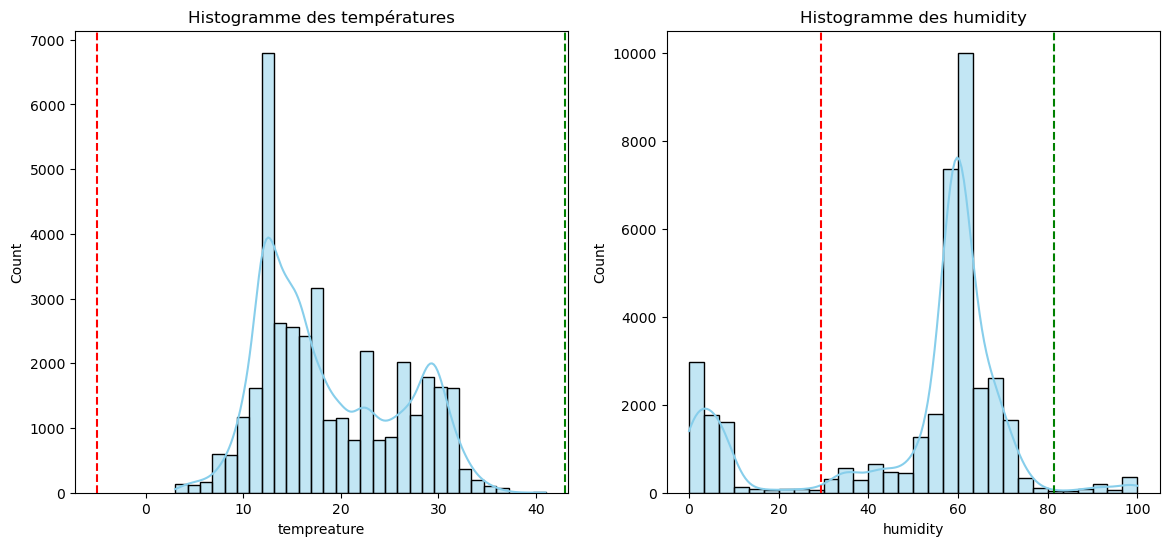

In [21]:
# Visualization
plt.figure(figsize=(14, 6))
# Histogram
plt.subplot(1, 2, 1)
sns.histplot(My_table['tempreature'], kde=True, bins=30, color='skyblue')
plt.axvline(lower_bound_temp, color='red', linestyle='--', label='Limite inférieure')
plt.axvline(upper_bound_temp, color='green', linestyle='--', label='Limite supérieure')
plt.title('Histogramme des températures')
# Histogram
plt.subplot(1, 2, 2)
sns.histplot(My_table['humidity'], kde=True, bins=30, color='skyblue')
plt.axvline(lower_bound_temp_1, color='red', linestyle='--', label='Limite inférieure')
plt.axvline(upper_bound_temp_1, color='green', linestyle='--', label='Limite supérieure')
plt.title('Histogramme des humidity')
plt.show()


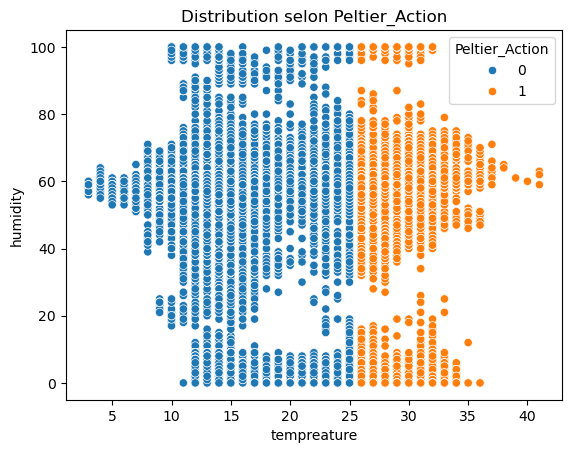

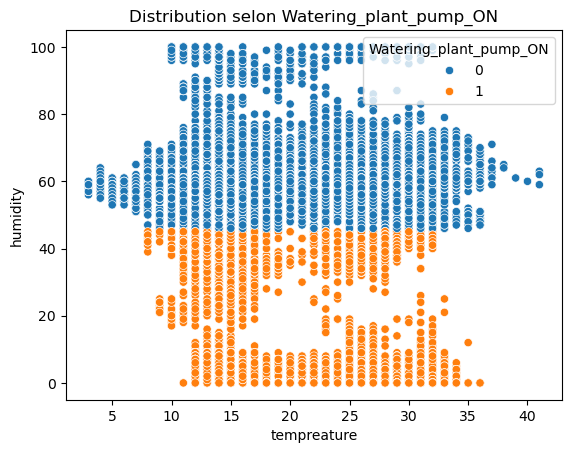

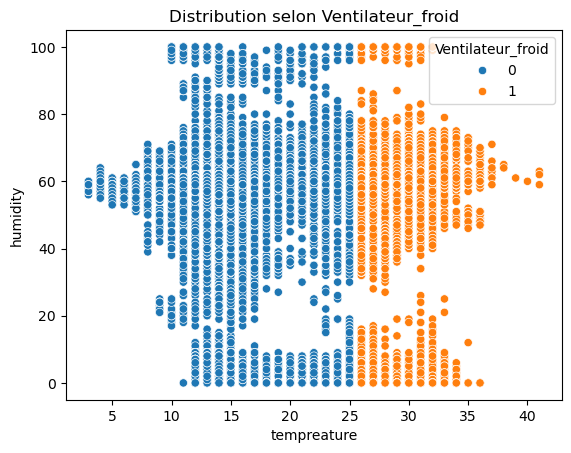

Text(0.5, 1.0, 'Distribution selon Heating_pad_Action')

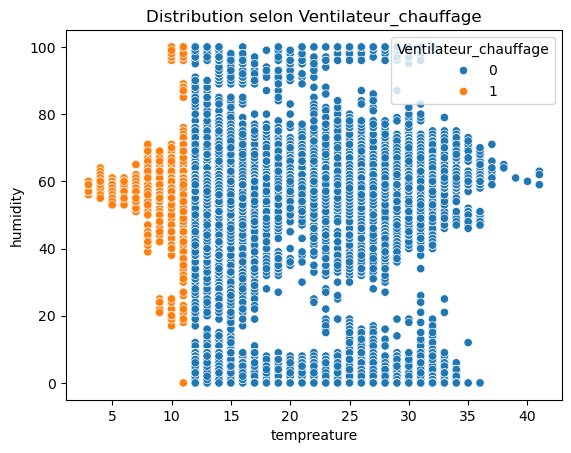

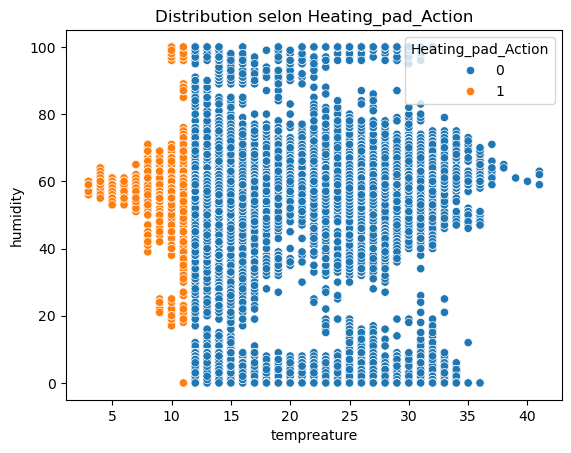

In [22]:
# Create a scatter plot for 'Peltier_Action'
plt.figure()
sns.scatterplot(data=My_table, x='tempreature', y='humidity', hue='Peltier_Action')
plt.title("Distribution selon Peltier_Action")
plt.show()

## Create a scatter plot for  'Watering_pump_status'
plt.figure()
sns.scatterplot(data=My_table, x='tempreature', y='humidity', hue='Watering_plant_pump_ON')
plt.title("Distribution selon Watering_plant_pump_ON")
plt.show()
## Create a scatter plot for  'Ventilateur_froid'
plt.figure()
sns.scatterplot(data=My_table, x='tempreature', y='humidity', hue='Ventilateur_froid')
plt.title("Distribution selon Ventilateur_froid")
plt.show()

## Create a scatter plot for  'Ventilateur_chauffage'
plt.figure()
sns.scatterplot(data=My_table, x='tempreature', y='humidity', hue='Ventilateur_chauffage')
plt.title("Distribution selon Ventilateur_chauffage")

## Create a scatter plot for  'Heating_pad_Action'
plt.figure()
sns.scatterplot(data=My_table, x='tempreature', y='humidity', hue='Heating_pad_Action')
plt.title("Distribution selon Heating_pad_Action")

In [23]:
Temperature = My_table['tempreature']
Peltier = My_table['Peltier_Action']

# Calcul de la corrélation de Pearson
r, p_value = pearsonr(Temperature, Peltier)
print("Corrélation de Pearson :", r)
print("P-value :", p_value)

Corrélation de Pearson : 0.8266328810902291
P-value : 0.0


In [24]:
humidity=My_table['humidity']
Waterting_pump=My_table['Watering_plant_pump_ON']
# Calcul de la corrélation de Pearson
c, p_value = pearsonr(humidity,Waterting_pump )
print("Corrélation de Pearson :", c)
print("P-value :", p_value)

Corrélation de Pearson : -0.9029093265920937
P-value : 0.0


In [25]:
tempreature=My_table['tempreature']
Ventilateur=My_table['Ventilateur_froid']
# Calcul de la corrélation de Pearson
c, p_value = pearsonr(tempreature,Ventilateur )
print("Corrélation de Pearson :", c)
print("P-value :", p_value)

Corrélation de Pearson : 0.8266328810902291
P-value : 0.0


In [26]:
tempreature=My_table['tempreature']
Ventilateur_chauffage=My_table['Ventilateur_chauffage']
# Calcul de la corrélation de Pearson
c, p_value = pearsonr(tempreature,Ventilateur_chauffage )
print("Corrélation de Pearson :", c)
print("P-value :", p_value)

Corrélation de Pearson : -0.47301602856754243
P-value : 0.0


In [27]:
Lamp_Status=My_table['Lamp_Status']
Timestamp_seconds=My_table['Timestamp_seconds']
# Calcul de la corrélation de Pearson
c, p_value = pearsonr(tempreature,Ventilateur_chauffage )
print("Corrélation de Pearson :", c)
print("P-value :", p_value)

Corrélation de Pearson : -0.47301602856754243
P-value : 0.0


In [28]:
My_table.to_csv('My_data.csv', index=False)

In [29]:
My_table

,tempreature,humidity,Watering_plant_pump_ON,Ventilateur_froid,Peltier_Action,Ventilateur_chauffage,Heating_pad_Action,Lamp_Status,Timestamp_seconds
0,41.0,63.0,0,1,1,0,0,0,1672531200
1,41.0,59.0,0,1,1,0,0,0,1672534800
2,41.0,62.0,0,1,1,0,0,0,1672538400
3,40.0,60.0,0,1,1,0,0,0,1672542000
4,39.0,61.0,0,1,1,0,0,0,1672545600
...,...,...,...,...,...,...,...,...,...
37917,3.0,59.0,0,0,0,1,1,0,1672606800
37918,3.0,60.0,0,0,0,1,1,0,1672610400
37919,3.0,60.0,0,0,0,1,1,0,1672614000
37920,3.0,59.0,0,0,0,1,1,0,1672531200


In [30]:
# Prepare the data
X =My_table [['tempreature', 'humidity','Timestamp_seconds']]
Y = My_table[['Watering_plant_pump_ON',
       'Ventilateur_froid', 'Peltier_Action', 'Ventilateur_chauffage',
       'Heating_pad_Action', 'Lamp_Status']]

In [31]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [32]:
# Split data into training, validation, and test sets
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X_scaled, Y, test_size=0.3, random_state=42 
)  

# Further split temporary sets into validation and test sets
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42
)

In [33]:
# Convert Y_train and Y_val to dictionaries for multi-output model
Y_train = {str(col): Y_train[col] for col in Y_train.columns}
Y_val = {str(col): Y_val[col] for col in Y_val.columns}

In [34]:
from tensorflow.keras.layers import LeakyReLU

inputs = Input(shape=(X_train.shape[1],))
x = Dense(64, kernel_regularizer='l2')(inputs)
x = LeakyReLU()(x)
x = BatchNormalization()(x)
#x = Dropout(0.3)(x)

x = Dense(32, kernel_regularizer='l2')(x)
x = LeakyReLU()(x)
#x = Dropout(0.3)(x)

x = Dense(16, kernel_regularizer='l2')(x)
x = LeakyReLU()(x)
#x = Dropout(0.3)(x)
outputs = [Dense(1, activation='sigmoid', name=str(col))(x) for col in Y_train.keys()]
model = Model(inputs=inputs, outputs=outputs)

In [35]:
optimizer = Adam(learning_rate=1e-3)
model.compile(optimizer=optimizer,
              loss={
                  'Watering_plant_pump_ON': 'binary_crossentropy',  # Changed key to match output layer name
                  'Ventilateur_froid': 'binary_crossentropy',  # Changed key to match output layer name
                  'Peltier_Action': 'binary_crossentropy',  # Changed key to match output layer name
                  'Ventilateur_chauffage': 'binary_crossentropy',  # Changed key to match output layer name
                  'Heating_pad_Action': 'binary_crossentropy',  # Changed key to match output layer name
                  'Lamp_Status': 'binary_crossentropy'  # Changed key to match output layer name
              },
              metrics={
                  'Watering_plant_pump_ON': 'accuracy',  # Changed key to match output layer name
                  'Ventilateur_froid': 'accuracy',  # Changed key to match output layer name
                  'Peltier_Action': 'accuracy',  # Changed key to match output layer name
                  'Ventilateur_chauffage': 'accuracy',  # Changed key to match output layer name
                  'Heating_pad_Action': 'accuracy',  # Changed key to match output layer name
                  'Lamp_Status': 'accuracy'  # Changed key to match output layer name
              })

In [36]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
history = model.fit(X_train, Y_train, validation_data=(X_val, Y_val), epochs=25, batch_size=16,callbacks=[early_stopping])



Epoch 1/25
1660/1660 ━━━━━━━━━━━━━━━━━━━━ 13s 5ms/step - Heating_pad_Action_accuracy: 0.9063 - Heating_pad_Action_loss: 0.2081 - Lamp_Status_accuracy: 0.8402 - Lamp_Status_loss: 0.3433 - Peltier_Action_accuracy: 0.9404 - Peltier_Action_loss: 0.1648 - Ventilateur_chauffage_accuracy: 0.9005 - Ventilateur_chauffage_loss: 0.2105 - Ventilateur_froid_accuracy: 0.9461 - Ventilateur_froid_loss: 0.1486 - Watering_plant_pump_ON_accuracy: 0.9544 - Watering_plant_pump_ON_loss: 0.1348 - loss: 1.7986 - val_Heating_pad_Action_accuracy: 0.9947 - val_Heating_pad_Action_loss: 0.0497 - val_Lamp_Status_accuracy: 0.9631 - val_Lamp_Status_loss: 0.1160 - val_Peltier_Action_accuracy: 0.9798 - val_Peltier_Action_loss: 0.0391 - val_Ventilateur_chauffage_accuracy: 0.9944 - val_Ventilateur_chauffage_loss: 0.0509 - val_Ventilateur_froid_accuracy: 0.9787 - val_Ventilateur_froid_loss: 0.0403 - val_Watering_plant_pump_ON_accuracy: 0.9907 - val_Watering_plant_pump_ON_loss: 0.0326 - val_loss: 0.6430
Epoch 2/25
1660/166

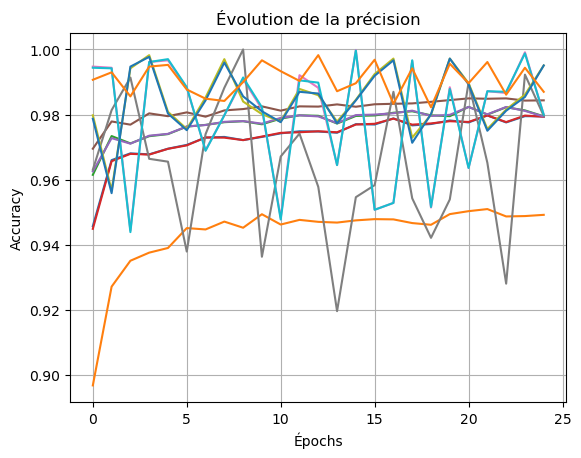

In [37]:
# Accuracy Curves
for key in history.history:
    if 'accuracy' in key:
        plt.plot(history.history[key], label=f"{key} d'entraînement")
    if 'val_accuracy' in key:
        plt.plot(history.history[key], label=f"{key} de validation")

plt.title("Évolution de la précision")
plt.xlabel("Épochs")
plt.ylabel("Accuracy")
plt.grid(True)
plt.show()

In [38]:
#Evaluate the Model on Test Data
test_loss, ventilateur_loss, ventilateur_chauffage_loss, peltier_loss, pump_loss, lamp_loss, heating_pad_loss, ventilateur_accuracy, ventilateur_chauffage_accuracy, peltier_accuracy, pump_accuracy, lamp_accuracy, heating_pad_accuracy = model.evaluate(
    X_test,
    {
        'Ventilateur_froid': Y_test['Ventilateur_froid'],
        'Ventilateur_chauffage': Y_test['Ventilateur_chauffage'], 
        'Peltier_Action': Y_test['Peltier_Action'], 
        'Watering_plant_pump_ON': Y_test['Watering_plant_pump_ON'], 
        'Lamp_Status': Y_test['Lamp_Status'], 
        'Heating_pad_Action': Y_test['Heating_pad_Action'] 
    },
    verbose=0
)

#Display the Results
print("Loss total sur les données de test :", test_loss)
print("Loss ventilateur froid :", ventilateur_loss)
print("Loss ventilateur chauffage :", ventilateur_chauffage_loss)
print("Loss peltier :", peltier_loss)
print("Loss pompe :", pump_loss)
print("Loss lampe :", lamp_loss)
print("Loss Heating pad :", heating_pad_loss)

print("Précision ventilateur froid :", ventilateur_accuracy)
print("Précision ventilateur chauffage :", ventilateur_chauffage_accuracy)
print("Précision peltier :", peltier_accuracy)
print("Précision pompe :", pump_accuracy)
print("Précision lampe :", lamp_accuracy)
print("Précision Heating pad :", heating_pad_accuracy)


Loss total sur les données de test : 0.22277091443538666
Loss ventilateur froid : 0.016869833692908287
Loss ventilateur chauffage : 0.02181321196258068
Loss peltier : 0.02184278704226017
Loss pompe : 0.018849186599254608
Loss lampe : 0.018393592908978462
Loss Heating pad : 0.04837210848927498
Précision ventilateur froid : 0.998593807220459
Précision ventilateur chauffage : 0.9936720132827759
Précision peltier : 0.9889259934425354
Précision pompe : 0.998593807220459
Précision lampe : 0.9892775416374207
Précision Heating pad : 0.9943751096725464


In [39]:
#Accuracy Curves
if 'accuracy' in history.history:  
    plt.figure(figsize=(12, 6))
    plt.plot(history.history['accuracy'], label="Précision d'entraînement", color='blue')
    plt.plot(history.history['val_accuracy'], label="Précision de validation", color='orange')
    plt.title("Évolution de la précision")
    plt.xlabel("Épochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

178/178 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


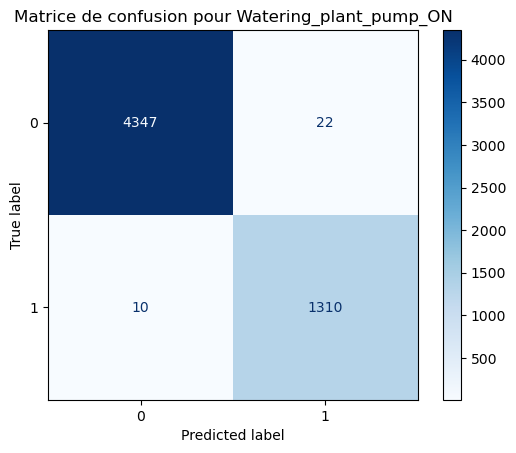

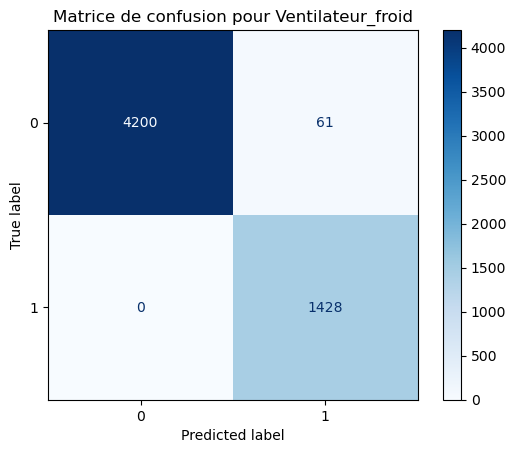

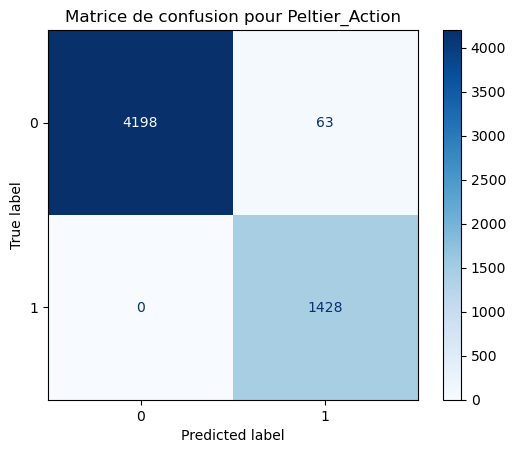

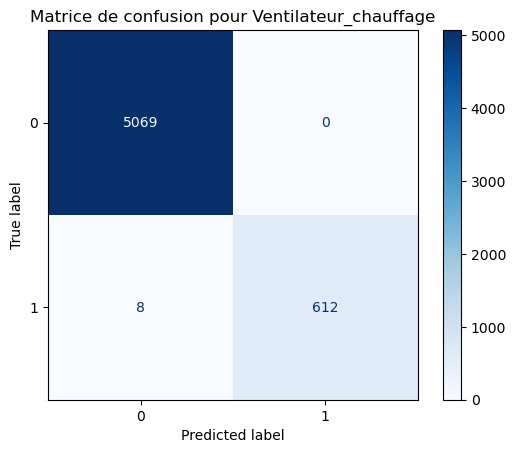

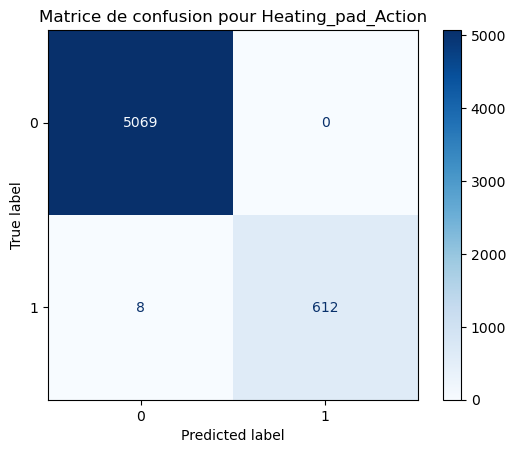

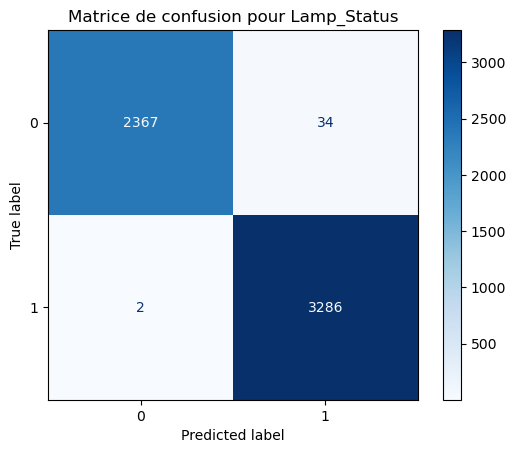

In [40]:
# Predictions on the Test Set
predictions = model.predict(X_test) 
#Create and Display a Confusion Matrix for Each Target
for i, target in enumerate(Y_test.columns): 
    if target == 'Peltier_Action':
        labels = sorted(Y_test[target].unique())
    else:
        labels = [0, 1]  
    target_predictions = predictions[i]

    # Apply threshold and convert to binary classes
    binary_predictions = (predictions[i] > 0.5).astype(int)  
    cm = confusion_matrix(Y_test[target], binary_predictions) 

    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)  
    disp.plot(cmap='Blues')  
    plt.title(f"Matrice de confusion pour {target}")
    plt.show()
